##  Importing Required Libraries

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from torchvision import datasets
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt


##  Loading and Preparing the Dataset

In [ ]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

train_dataset = datasets.ImageFolder("/content/images/train", transform=transform)
val_dataset = datasets.ImageFolder("/content/images/val", transform=transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

num_classes = len(train_dataset.classes)
print("Classes:", num_classes)


Classes: 38


In [ ]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


##  Building the MLP Model

In [22]:
class MLP(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(224*224*3, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        return self.net(x)

mlp_model = MLP(num_classes).to(device)


In [23]:
criterion = nn.CrossEntropyLoss()
mlp_optimizer = optim.Adam(mlp_model.parameters(), lr=0.001)


##  Training and Validation Functions

In [24]:
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    avg_loss = total_loss / len(loader)
    accuracy = 100 * correct / total
    return avg_loss, accuracy


In [25]:
def validate(model, loader, criterion):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    avg_loss = total_loss / len(loader)
    accuracy = 100 * correct / total
    return avg_loss, accuracy


##  Training the MLP Model

In [27]:
mlp_train_loss = []
mlp_val_loss = []
mlp_train_acc = []
mlp_val_acc = []

epochs = 5

for epoch in range(epochs):
    train_loss, train_acc = train_one_epoch(
        mlp_model, train_loader, mlp_optimizer, criterion
    )
    val_loss, val_acc = validate(
        mlp_model, val_loader, criterion
    )

    mlp_train_loss.append(train_loss)
    mlp_val_loss.append(val_loss)
    mlp_train_acc.append(train_acc)
    mlp_val_acc.append(val_acc)

    print(
        f"Epoch [{epoch+1}/{epochs}] | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.2f}% | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.2f}%"
    )


Epoch [1/5] | Train Loss: 2.9807 | Train Acc: 20.68% | Val Loss: 2.9940 | Val Acc: 21.03%
Epoch [2/5] | Train Loss: 2.9383 | Train Acc: 20.79% | Val Loss: 2.9537 | Val Acc: 21.20%
Epoch [3/5] | Train Loss: 2.9144 | Train Acc: 21.12% | Val Loss: 2.9499 | Val Acc: 21.81%
Epoch [4/5] | Train Loss: 2.8916 | Train Acc: 21.39% | Val Loss: 2.8841 | Val Acc: 20.77%
Epoch [5/5] | Train Loss: 2.8758 | Train Acc: 21.32% | Val Loss: 2.8660 | Val Acc: 21.00%


##  Building the CNN Model

In [28]:
class CNN(nn.Module):
    def __init__(self, num_classes):
        super(CNN, self).__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 28 * 28, 256),
            nn.ReLU(),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

cnn_model = CNN(num_classes).to(device)


In [29]:
cnn_optimizer = optim.Adam(cnn_model.parameters(), lr=0.001)


##  Training the CNN Model

In [30]:
cnn_train_loss = []
cnn_val_loss = []
cnn_train_acc = []
cnn_val_acc = []

epochs = 10

for epoch in range(epochs):
    train_loss, train_acc = train_one_epoch(
        cnn_model, train_loader, cnn_optimizer, criterion
    )
    val_loss, val_acc = validate(
        cnn_model, val_loader, criterion
    )

    cnn_train_loss.append(train_loss)
    cnn_val_loss.append(val_loss)
    cnn_train_acc.append(train_acc)
    cnn_val_acc.append(val_acc)

    print(
        f"Epoch [{epoch+1}/{epochs}] | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.2f}% | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.2f}%"
    )


Epoch [1/10] | Train Loss: 0.8974 | Train Acc: 73.47% | Val Loss: 0.4002 | Val Acc: 86.95%
Epoch [2/10] | Train Loss: 0.2958 | Train Acc: 90.46% | Val Loss: 0.3317 | Val Acc: 88.90%
Epoch [3/10] | Train Loss: 0.1610 | Train Acc: 94.84% | Val Loss: 0.3494 | Val Acc: 89.71%
Epoch [4/10] | Train Loss: 0.1064 | Train Acc: 96.49% | Val Loss: 0.3647 | Val Acc: 89.94%
Epoch [5/10] | Train Loss: 0.0788 | Train Acc: 97.52% | Val Loss: 0.3331 | Val Acc: 91.15%
Epoch [6/10] | Train Loss: 0.0699 | Train Acc: 97.77% | Val Loss: 0.4090 | Val Acc: 90.43%
Epoch [7/10] | Train Loss: 0.0576 | Train Acc: 98.16% | Val Loss: 0.3131 | Val Acc: 92.60%
Epoch [8/10] | Train Loss: 0.0485 | Train Acc: 98.48% | Val Loss: 0.3592 | Val Acc: 91.84%
Epoch [9/10] | Train Loss: 0.0420 | Train Acc: 98.65% | Val Loss: 0.3593 | Val Acc: 92.39%
Epoch [10/10] | Train Loss: 0.0426 | Train Acc: 98.63% | Val Loss: 0.4033 | Val Acc: 91.95%


MLP Loss Curve

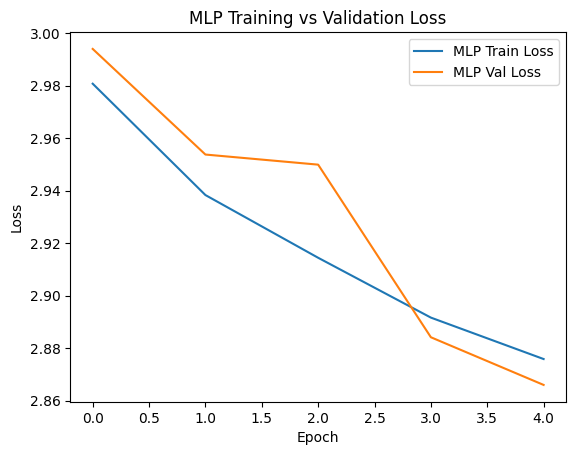

In [31]:
plt.plot(mlp_train_loss, label="MLP Train Loss")
plt.plot(mlp_val_loss, label="MLP Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("MLP Training vs Validation Loss")
plt.legend()
plt.show()


CNN Loss Curve

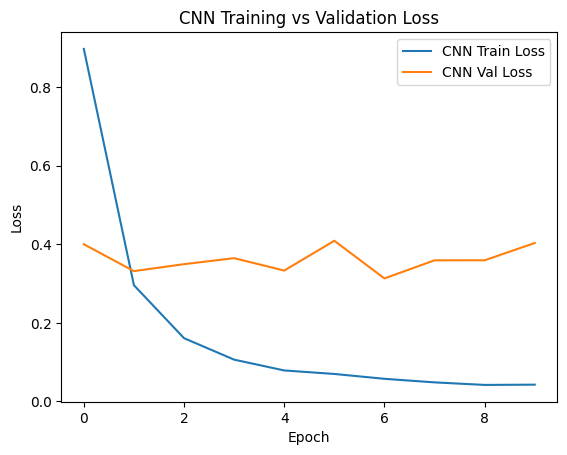

In [32]:
plt.plot(cnn_train_loss, label="CNN Train Loss")
plt.plot(cnn_val_loss, label="CNN Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CNN Training vs Validation Loss")
plt.legend()
plt.show()


Comparison

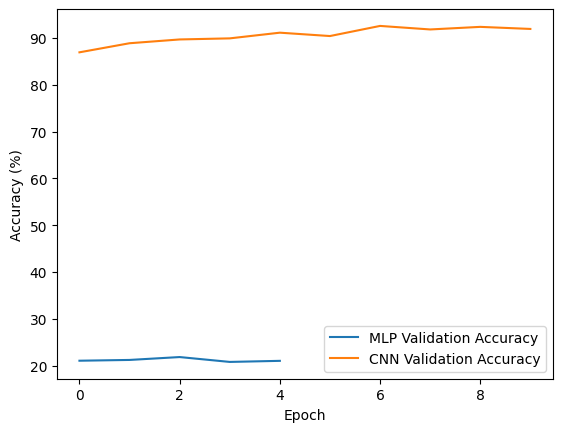

In [33]:
plt.plot(mlp_val_acc, label="MLP Validation Accuracy")
plt.plot(cnn_val_acc, label="CNN Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.legend()
plt.show()


Testing both models

In [34]:
import random
import torch.nn.functional as F


In [35]:
def test_model_on_samples(model, dataset, num_samples=6):
    model.eval()

    indices = random.sample(range(len(dataset)), num_samples)

    plt.figure(figsize=(15, 8))

    for i, idx in enumerate(indices):
        image, true_label = dataset[idx]

        image_input = image.unsqueeze(0).to(device)

        with torch.no_grad():
            output = model(image_input)
            probs = F.softmax(output, dim=1)
            confidence, predicted_label = torch.max(probs, 1)

        predicted_label = predicted_label.item()
        confidence = confidence.item() * 100

        class_names = dataset.classes

        plt.subplot(2, 3, i + 1)
        plt.imshow(image.permute(1, 2, 0))
        plt.axis("off")

        title_color = "green" if predicted_label == true_label else "red"

        plt.title(
            f"Actual: {class_names[true_label]}\n"
            f"Predicted: {class_names[predicted_label]}\n"
            f"Confidence: {confidence:.2f}%",
            color=title_color
        )

    plt.tight_layout()
    plt.show()


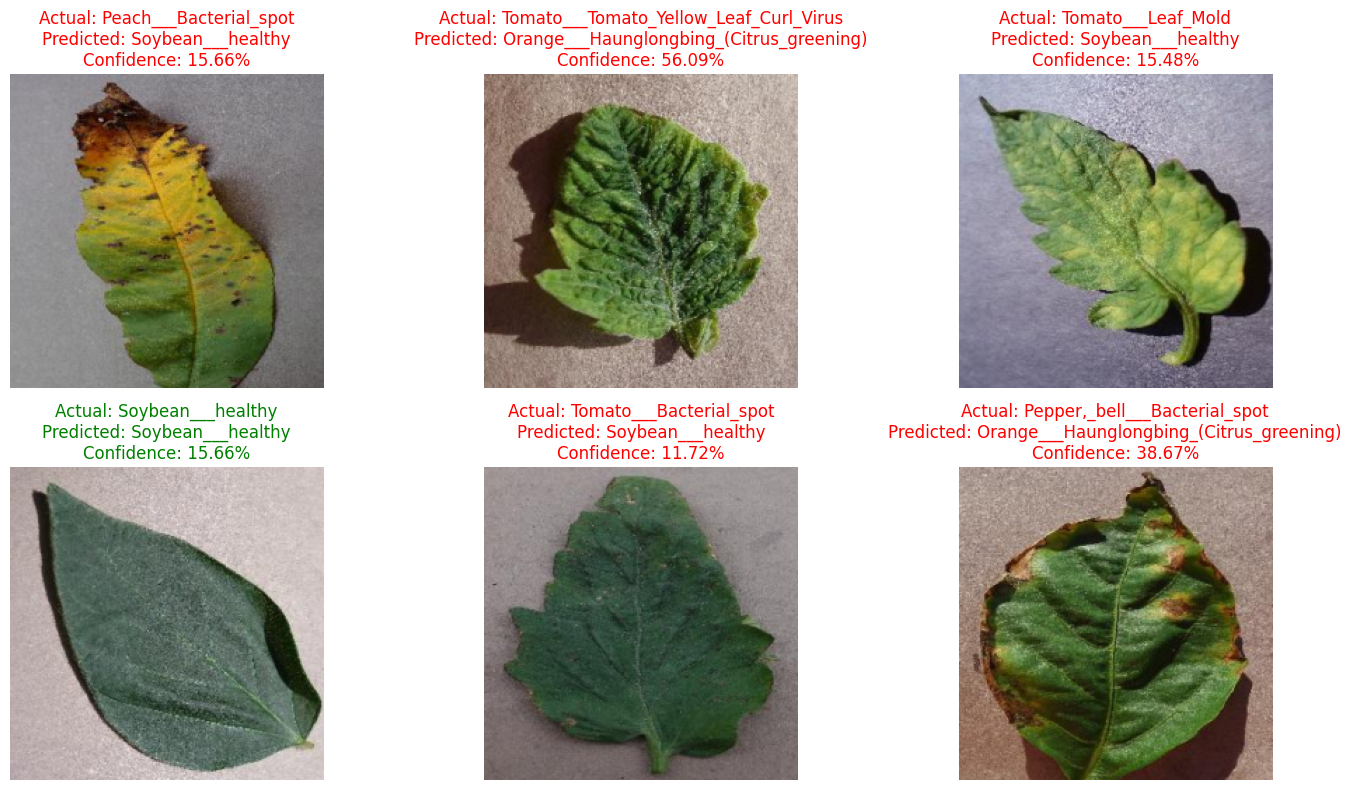

In [36]:
test_model_on_samples(mlp_model, val_dataset)
